In [4]:
#| code-fold: true
import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.optimize import curve_fit
import pydeck as pdk
import matplotlib.pyplot as plt


import seaborn as sns
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

# Set Seaborn color palette
cmap = 'Set2'
sns.set_palette(cmap)

# Update Matplotlib rcParams
mpl.rcParams.update({
    #'font.family': 'Consolas',  # Font family for all text
    'figure.dpi': 200,  # High resolution for figures
    
    # Axes settings
    'axes.titlesize': 12,  # Font size for the axes title
    'axes.titleweight': 'normal',  # Weight for the axes title
    'axes.labelsize': 10,  # Font size for the axes labels
    
    # Tick settings
    'xtick.direction': 'in',  # Ticks pointing inwards
    'ytick.direction': 'in',  # Ticks pointing inwards
    'xtick.minor.visible': True,  # Show minor ticks on x-axis
    'ytick.minor.visible': True,  # Show minor ticks on y-axis

    # Grid settings
    'axes.grid': True,  # Enable grid by default
    'axes.grid.which': 'both',  # Show both major and minor grids
    'grid.linestyle': ':',  # Dotted grid lines
    'grid.alpha': 0.3,  # Transparency for major grid lines
    'grid.linewidth': 0.6,  # Line width for major grid lines

})


plt.rcParams['ytick.right'] = plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.left'] = plt.rcParams['ytick.labelleft'] = True

# Introduction
Arsenic contamination of groundwater has created a public health crisis in Bangladesh. It affects millions of people who rely on the contaminated water for drinking and domestic purposes. The extent of this contamination varies widely across the country, with some areas having dangerously high levels [@HOSSAIN20061].
The contamination originates from naturally occurring arsenic in the aquifer sediments, which is mobilized into groundwater through geochemical processes. The most widely supported explanation is the reductive dissolution of iron oxyhydroxides under anoxic conditions[@Nickson1998], though some studies suggest that irrigation-induced oxidation may also play a role in certain areas[@HOSSAIN20061].
Robust methods are needed to predict where arsenic concentrations will exceed safety thresholds, given the widespread reliance on groundwater and the health risks of arsenic exposure. Geostatistical indicator techniques provide a powerful approach to this challenge, allowing the assessment and mapping of the risk of arsenic contamination above critical levels such as 10 µg/l and 50 µg/l. Specifically, Indicator Simulation and kriging can be used to generate maps to provides valuable information for risk assessment and mitigation strategies.

# Dataset and area of interest
This analysis uses a dataset of concentrations of different species measured in irregularly spaced groundwater wells in Bangladesh. The data were collected in 1998 and 1999, and our analysis uses only arsenic concentrations. In addition, a simple boundary shape of Bangladesh is used for this analysis.
To simplify the analysis, values below the detection limit of 6 or 5 are replaced by 5 or 6 $\mu g/ l$, depending on the detector.
The Dataset contains unique Sample IDs and unique Sample Field IDs but revelas that there are 113 duplicates or more occurences of the same coordinate pairs. These double Coordinate pairs are removed because the would result in a singular linear equation system for the Kriging interpolation.
As a coordinate regerence system the data is stored as WGS84 for the analysis the dataset is reprojected to the local EPSG:9678 coordinate reference system.

In [13]:
fp_table = r"data/NationalSurveyData.csv"
d = pd.read_csv(fp_table,sep=",",skipinitialspace=True,skiprows=(0,1,2,3,5,6),)
shp = gpd.read_file(r"data/borders.shp")

d["As"] = d['As'].str.replace(r"^<", "", regex=True).astype(float)
duplicates = np.unique(d[["LAT_DEG","LONG_DEG"]],axis=0,return_counts=True)
d = d.drop_duplicates(subset=["LAT_DEG", "LONG_DEG"])

# Create a GeoDataFrame from the DataFrame and lat/lon lists
dg = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(d["LONG_DEG"], d["LAT_DEG"]))
# Set the coordinate reference system to WGS84 (EPSG:4326)
dg = dg.set_crs(epsg=4326, inplace=True)

main_crs = "EPSG:9678" # https://epsg.io/9678
dg = dg.to_crs(main_crs)
shp = shp.to_crs(main_crs)

The raw data can now be displayed in @fig-data. The map displays the distribution of arsenic concentration in Bangladesh, with green dots representing areas of low arsenic levels and pink dots indicating regions with higher contamination. The green dots are widespread across the northern, western, and parts of the eastern regions, while the pink dots are concentrated mainly in the central and southeastern areas, particularly around the Ganges Delta.

In [17]:
#| code-fold: true
#| label: fig-data
#| fig-cap: "arsenic concentration in Bangladesh"
vmax = np.percentile(dg["As"], 95)
m = dg.explore(column="As", cmap="PiYG_r", tiles="CartoDB positron", vmax=vmax)
shp.boundary.explore(m=m, style_kwds={"fill": False, "color": "black"})

# Methods

We assume to hava a set of random sampled observations at the postions $\mathbf{x_p}$ with assigned observations of a certain attribute $Z(\mathbf{x_p})$. These attributes may are distributed according to their postion. In order to interpolate the given attribute field $Z(\mathbf{x})$ the spatial variability of $Z(\mathbf{x})$ has to be described and can then be used to perform the covariance based interpolation.

## Variogram

_Empirical Variogram_

These attribute values will have certain stochastic properties. Furthermore the stochastic properties are connected to the spatial distribution of the points - or they are not. In order to describe this, we analyze the spatial variabiability of our attribute $Z(\mathbf{x_p})$ using a Variogram.
The Variogram describes the (Semi-) Variance of our measured values according to their distance to other observations inside our probe.

The variograms semivarinace is calculated as followed:

$$
γ(h)=\frac{1}{2N(h)} \sum_{i=1}^{N}(Z(x_i+h)−Z(x_i))^2 
$$

the variogram measures the half mean squared difference of the data values of $Z$.
where $h$ is the distance between points in the lag class, $N(h)$ is the number of points with the distance h (Number of points per lag class). And $x_i$ is the position of the i-th point and $Z$ is the attribute value at the position $x_i$. $x_i$ is element of $\mathbf{x_p}$
[@schlaues_buch]

_Theoretical Variogram_

With the semivariogram we yield an empirical description of the spatial variability using lag classes for $h$. In order to derive a continuous semivariance, a theoretical model is fitted to the discrete data points in our variogram.
Certain variogram models exist for different purposes and data characteristics. The most widely used models are the Spherical Model, the Exponential Model, and the Gaussian Model. More models exist.

Based on our study area and the measured variable, the Arsen concentration, the choose the Sphreical Model for further analyis. It is well fitted for observations of concentrations or contamination [@schlaues_buch]

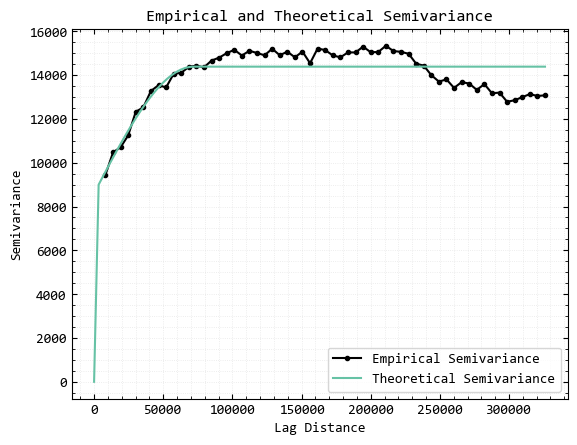     __Hier Grafik ersetzen__

Generally, the variogram is described by 3 paramters. The Sill, the maximum semivarinace the distribution reaches. The Nugget, is the ofset between zero and the lowest semivariance at $h=0$. And the Range, is the maximum $h$ value from where to semivarinace becomes constant and is not increasing anymore.

The formula for the spherical variogram model is given by:

$$
\gamma(h) = 
\begin{cases}
0 & \text{if } h = 0 \\
C_0 + C_1 \left[ \frac{3h}{2a} - \frac{1}{2} \left( \frac{h}{a} \right)^3 \right] & \text{if } 0 < h \leq a \\
C_0 + C_1 & \text{if } h > a 
\end{cases}
$$

where:
- $h$ is the lag distance,
- $C_0$ is the nugget,
- $C_1$ is the sill minus the nugget, (_Note:_ Sill is $C=C_0+C_1$)
- $a$ is the range.



The semivarinace describes the variablitly in our dataset, but for the interpolation tasks we need a measure of the covarinace between our datapoints. The semivariance is directly related to covarinace by the term:

$$Cov(h) = Var(Z) - \gamma(h)$$

Because the sill in our variogramm is the $Var(Z)$ the equation can be easily solved. Or the Covarinace can be calculated directly from the parameters $C_0, C_1, a$.

The Covariance is derived from the Semmivariance:

$$
Cov(h) = 
\begin{cases} 
C_0 + C_1 & \text{if } h = 0 \\
C_1 - C_1 \left[ \frac{3h}{2a} - \frac{1}{2} \left( \frac{h}{a} \right)^3 \right] & \text{if } 0 < h \leq a \\
0 & \text{if } h > a 
\end{cases}
$$


## Kriging

Krigin as an interpolation technique from the field of geostatistics that uses distance and correlation between the sample points to find the best estimator. Kriging meets the conditions to be the Best Linear Unbiased Estimator (BLUE).

_"Kriging is basically a generalization of minimum mean square error estimation taking into account spatial correlation"_ [@sagar2018]

Kriging is based on the work by the south african miner Danie G. Krige. Several variations of Kriging exists. We discusse the simplest form Simple Kriging, Ordinary Krigin, and Indicator Krigin in this chapter.

In general the estimaton of the attribute value $Z^*(\mathbf{x_0})$ at the interpolation location $\mathbf{x_0}$ is calculated with the weighted mean from the sourrounding points. The weights are based on the variogram modell and thus on the correlation between datapoints.


$$
Z^*_{OK}(x_0) = \sum_{i=0}^{n} \lambda_i \cdot z(x_i)
$$

This can be demonstrated with the Ordinary Kringing estimator for example. Where $n\leq N$ is a subset of points from the observations closest to the interpolation location. z is the attribut value from the ith observation, and $\lambda_i$ is the weight determined by solving an equation system of the covariance (see next section [@sagar2018])

### Simple Kriging
The Weigths for the Kriging are Calulated via the Covariance for each interpolation point:

$$
\lambda = \mathbf{C^{-1} \cdot c_0}
$$

the matrizes looks like that:



$$
\lambda =
\begin{bmatrix}
    \lambda_1 \\
    \lambda_2 \\
    \vdots \\
    \lambda_2
\end{bmatrix}, \quad
\mathbf{C} =
\begin{bmatrix}
    \text{Cov}[x_1, x_1] & \text{Cov}[x_1, x_2] & \cdots & \text{Cov}[x_1, x_n] \\
    \text{Cov}[x_2, x_1] & \text{Cov}[x_2, x_2] & \cdots & \text{Cov}[x_2, x_n] \\
    \vdots & \vdots & \ddots & \vdots \\
    \text{Cov}[x_n, x_1] & \text{Cov}[x_n, x_2] & \cdots & \text{Cov}[x_n, x_n]
\end{bmatrix}, \quad
\mathbf{c}_0 =
\begin{bmatrix}
    \text{Cov}(x_1, x_0) \\
    \text{Cov}(x_2, x_0) \\
    \vdots \\
    \text{Cov}(x_n, x_0)
\end{bmatrix}
$$

The estimator for $\mathbf{x_0}$ is calculated like:

\begin{align*}

Z^*_{SK}(x_0) &= \sum_{i=0}^{n} \lambda_i \cdot (z(x_i) - m) + m \\

\\
\Leftrightarrow \ \

Z^*_{SK}(x_0) &= \lambda^{T} \cdot (\mathbf{Z} - m) + m
\end{align*}

The last line is the matrix notation that can be used in python for a faster implementation of the operations.
Note that $m=m(x)=constant$ is the mean of $Z$ in the study area

### Ordinary Kriging

Ordinary Kringing fullfills the constraint 

$$
\sum_{i=0}^{n} \lambda_i \overset{!}{=} 1
$$

what leads the the estimation of the espected value (E) in each local neighborhood and ensures the unbiasedness of the estimator.

The Matrix form with the condition:

$$
\lambda =
\begin{bmatrix}
\lambda_1 \\
\lambda_2 \\
\vdots \\
\lambda_n \\
\mu_{OK}
\end{bmatrix},
\quad
\mathbf{C} =
\begin{bmatrix}
\text{Cov}[x_1, x_1] & \text{Cov}[x_1, x_2] & \dots & \text{Cov}[x_1, x_n] & 1 \\
\text{Cov}[x_2, x_1] & \text{Cov}[x_2, x_2] & \dots & \text{Cov}[x_2, x_n] & 1 \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
\text{Cov}[x_n, x_1] & \text{Cov}[x_n, x_2] & \dots & \text{Cov}[x_n, x_n] & 1 \\
1 & 1 & \dots & 1 & 0
\end{bmatrix},
\quad
\mathbf{C_0} =
\begin{bmatrix}
\text{Cov}(x_1, x_0) \\
\text{Cov}(x_2, x_0) \\
\vdots \\
\text{Cov}(x_n, x_0) \\
1
\end{bmatrix}
$$


From $\lambda = \mathbf{C^{-1} \cdot c_0}$ the weight are calculated.

The estimate at every ${x_0}$ is calculated with:

$$
Z^*_{OK}(x_0) = \sum_{i=0}^{n} \lambda_i \cdot z(x_i)
$$

or the matrix representation

$\Leftrightarrow  $
$$Z^*_{OK}(x_0) = \lambda^{T} \cdot \mathbf{Z}$$

With $\mathbf{Z}$ beeing the list of all observed values and $\lambda^{T}$ the corresponding weights both resulting in one scalar value $Z^*_{OK}(x_0)$.

### Indicator Kriging

...

## Geostatistical Simulation

### Sequential Indicator Simulation
...

# Results

# Discussion an comparison to Ordinary Kriging 

# References